THis 4 cells are about the data upload and verification

In [2]:

!pip install -q pyarrow seaborn


In [3]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

train = "/Users/raresolteanu/Downloads/ts-forecasting/train.parquet"
test = "/Users/raresolteanu/Downloads/ts-forecasting/test.parquet"


train_pf = pq.ParquetFile(train)
test_pf = pq.ParquetFile(test)

all_cols = train_pf.schema.names
feature_cols = []

for col in all_cols:
    if col.startswith("feature_"):
        feature_cols.append(col)

print("number of features:", len(feature_cols))
print(feature_cols[:5])
print(feature_cols[:86])


number of features: 86
['feature_a', 'feature_b', 'feature_c', 'feature_d', 'feature_e']
['feature_a', 'feature_b', 'feature_c', 'feature_d', 'feature_e', 'feature_f', 'feature_g', 'feature_h', 'feature_i', 'feature_j', 'feature_k', 'feature_l', 'feature_m', 'feature_n', 'feature_o', 'feature_p', 'feature_q', 'feature_r', 'feature_s', 'feature_t', 'feature_u', 'feature_v', 'feature_w', 'feature_x', 'feature_y', 'feature_z', 'feature_aa', 'feature_ab', 'feature_ac', 'feature_ad', 'feature_ae', 'feature_af', 'feature_ag', 'feature_ah', 'feature_ai', 'feature_aj', 'feature_ak', 'feature_al', 'feature_am', 'feature_an', 'feature_ao', 'feature_ap', 'feature_aq', 'feature_ar', 'feature_as', 'feature_at', 'feature_au', 'feature_av', 'feature_aw', 'feature_ax', 'feature_ay', 'feature_az', 'feature_ba', 'feature_bb', 'feature_bc', 'feature_bd', 'feature_be', 'feature_bf', 'feature_bg', 'feature_bh', 'feature_bi', 'feature_bj', 'feature_bk', 'feature_bl', 'feature_bm', 'feature_bn', 'feature_bo'

In [4]:
train_ids = pq.read_table(train, columns=["id"]).to_pandas()
test_ids = pq.read_table(test, columns=["id"]).to_pandas()

print("train duplicate ids:", train_ids["id"].duplicated().sum())
print("test duplicate ids:", test_ids["id"].duplicated().sum())


train duplicate ids: 0
test duplicate ids: 0


In [5]:
train_pf.num_row_groups


17

In [6]:
import pyarrow.parquet as pq

train_pf = pq.ParquetFile(train)
test_pf = pq.ParquetFile(test)

print("train row groups:", train_pf.num_row_groups)
print("test row groups:", test_pf.num_row_groups)


train row groups: 17
test row groups: 6


In [7]:
for i in range(train_pf.num_row_groups):
    table = train_pf.read_row_group(i, columns=["ts_index"])
    print("train row group", i, "rows:", table.num_rows)


train row group 0 rows: 345587
train row group 1 rows: 349195
train row group 2 rows: 345737
train row group 3 rows: 327667
train row group 4 rows: 324524
train row group 5 rows: 262150
train row group 6 rows: 262149
train row group 7 rows: 341447
train row group 8 rows: 328224
train row group 9 rows: 342077
train row group 10 rows: 268673
train row group 11 rows: 309413
train row group 12 rows: 334447
train row group 13 rows: 262161
train row group 14 rows: 347794
train row group 15 rows: 348270
train row group 16 rows: 237899


In [8]:
for i in range(test_pf.num_row_groups):
    table = test_pf.read_row_group(i, columns=["ts_index"])
    print("test row group", i, "rows:", table.num_rows)


test row group 0 rows: 271332
test row group 1 rows: 271332
test row group 2 rows: 271332
test row group 3 rows: 271332
test row group 4 rows: 271332
test row group 5 rows: 90447


In [9]:
train_missing = {}
test_missing = {}

for col in feature_cols:
    train_missing[col] = 0
    test_missing[col] = 0
train_rows = 0
test_rows = 0

for i in range(train_pf.num_row_groups):
    df = train_pf.read_row_group(i, columns=feature_cols).to_pandas()
    train_rows += len(df)

    for col in feature_cols:
        train_missing[col] += df[col].isna().sum()

# test
for i in range(test_pf.num_row_groups):
    df = test_pf.read_row_group(i, columns=feature_cols).to_pandas()
    test_rows += len(df)

    for col in feature_cols:
        test_missing[col] += df[col].isna().sum()

print("missing values check done")


missing values check done


In [10]:
print(train_rows)
print(test_rows)

5337414
1447107


In [11]:
print(train_missing)
print(test_missing)

{'feature_a': 0, 'feature_b': 0, 'feature_c': 0, 'feature_d': 0, 'feature_e': 0, 'feature_f': 0, 'feature_g': 0, 'feature_h': 58465, 'feature_i': 59025, 'feature_j': 58465, 'feature_k': 59025, 'feature_l': 1300, 'feature_m': 38170, 'feature_n': 8906, 'feature_o': 6258, 'feature_p': 6362, 'feature_q': 7122, 'feature_r': 8906, 'feature_s': 6258, 'feature_t': 6362, 'feature_u': 7122, 'feature_v': 6154, 'feature_w': 6184, 'feature_x': 6184, 'feature_y': 6184, 'feature_z': 6184, 'feature_aa': 6154, 'feature_ab': 6362, 'feature_ac': 7122, 'feature_ad': 8906, 'feature_ae': 8126, 'feature_af': 8126, 'feature_ag': 8126, 'feature_ah': 6154, 'feature_ai': 0, 'feature_aj': 8126, 'feature_ak': 8126, 'feature_al': 225416, 'feature_am': 0, 'feature_an': 0, 'feature_ao': 0, 'feature_ap': 0, 'feature_aq': 0, 'feature_ar': 0, 'feature_as': 0, 'feature_at': 665676, 'feature_au': 38447, 'feature_av': 38654, 'feature_aw': 205194, 'feature_ax': 38409, 'feature_ay': 455920, 'feature_az': 11157, 'feature_ba':

In [12]:
train_missing_df = pd.DataFrame(train_missing.items(), columns=["feature", "missing_count"])
train_missing_df = train_missing_df.sort_values("missing_count", ascending=False)

test_missing_df = pd.DataFrame(test_missing.items(), columns=["feature", "missing_count"])
test_missing_df = test_missing_df.sort_values("missing_count", ascending=False)

In [13]:
print(train_missing_df)
print(test_missing_df)

       feature  missing_count
45  feature_at         665676
76  feature_by         588140
50  feature_ay         455920
81  feature_cd         400114
82  feature_ce         275829
..         ...            ...
55  feature_bd              0
56  feature_be              0
57  feature_bf              0
58  feature_bg              0
85  feature_ch              0

[86 rows x 2 columns]
       feature  missing_count
23   feature_x         558243
25   feature_z         558243
22   feature_w         558243
24   feature_y         558243
45  feature_at         133629
..         ...            ...
32  feature_ag              0
33  feature_ah              0
34  feature_ai              0
35  feature_aj              0
85  feature_ch              0

[86 rows x 2 columns]


In [14]:
train_missing_df = train_missing_df[train_missing_df["missing_count"] > 0]
train_missing_df = train_missing_df.sort_values("missing_count", ascending=False)

test_missing_df = test_missing_df[test_missing_df["missing_count"] > 0]
test_missing_df = test_missing_df.sort_values("missing_count", ascending=False)

print("TRAIN")
print(train_missing_df)

print("TEST")
print(test_missing_df)


TRAIN
       feature  missing_count
45  feature_at         665676
76  feature_by         588140
50  feature_ay         455920
81  feature_cd         400114
82  feature_ce         275829
83  feature_cf         236389
37  feature_al         225416
48  feature_aw         205194
77  feature_bz         151722
60  feature_bi         147432
10   feature_k          59025
8    feature_i          59025
9    feature_j          58465
7    feature_h          58465
84  feature_cg          39644
47  feature_av          38654
46  feature_au          38447
49  feature_ax          38409
12   feature_m          38170
51  feature_az          11157
63  feature_bl          11157
17   feature_r           8906
29  feature_ad           8906
13   feature_n           8906
30  feature_ae           8126
31  feature_af           8126
36  feature_ak           8126
32  feature_ag           8126
35  feature_aj           8126
28  feature_ac           7122
16   feature_q           7122
20   feature_u           7122
27  

In [15]:
train_missing_df["missing_pct"] = train_missing_df["missing_count"] / train_rows
test_missing_df["missing_pct"] = test_missing_df["missing_count"] / test_rows


In [16]:
print(train_missing_df.tail(86))
print(test_missing_df.tail(86))


       feature  missing_count  missing_pct
45  feature_at         665676     0.124719
76  feature_by         588140     0.110192
50  feature_ay         455920     0.085420
81  feature_cd         400114     0.074964
82  feature_ce         275829     0.051678
83  feature_cf         236389     0.044289
37  feature_al         225416     0.042233
48  feature_aw         205194     0.038444
77  feature_bz         151722     0.028426
60  feature_bi         147432     0.027622
10   feature_k          59025     0.011059
8    feature_i          59025     0.011059
9    feature_j          58465     0.010954
7    feature_h          58465     0.010954
84  feature_cg          39644     0.007428
47  feature_av          38654     0.007242
46  feature_au          38447     0.007203
49  feature_ax          38409     0.007196
12   feature_m          38170     0.007151
51  feature_az          11157     0.002090
63  feature_bl          11157     0.002090
17   feature_r           8906     0.001669
29  feature

In [17]:
some_features = ["feature_a", "feature_b", "feature_c", "feature_d"]

small_df = pq.read_table(
    train,
    columns=["ts_index", "horizon", "y_target"] + some_features,
).to_pandas()

print(small_df.head())


   ts_index  horizon  y_target  feature_a  feature_b  feature_c  feature_d
0        89       25 -0.551324         29  16.364093   7.464023   5.966933
1        89        1 -0.315583         53   2.858806   5.050617  15.906651
2        89        3 -0.362894         51   9.585452   1.076268   9.004147
3        89       10 -0.667023         44   8.840588  15.034634   4.170780
4        90       25 -0.437398         28   2.303825   7.696209  12.896100


In [18]:
print(small_df[some_features].describe())


          feature_a     feature_b     feature_c     feature_d
count  5.337414e+06  5.337414e+06  5.337414e+06  5.337414e+06
mean   8.868155e+01  8.567391e+00  8.564846e+00  8.565059e+00
std    5.603141e+01  4.869982e+00  4.869406e+00  4.871465e+00
min    0.000000e+00  1.300042e-01  1.300016e-01  1.300009e-01
25%    4.000000e+01  4.350043e+00  4.350582e+00  4.346282e+00
50%    8.400000e+01  8.568381e+00  8.563840e+00  8.567354e+00
75%    1.330000e+02  1.278265e+01  1.278253e+01  1.278491e+01
max    2.130000e+02  1.700000e+01  1.700000e+01  1.700000e+01


In [19]:
for col in some_features:
    corr = small_df[[col, "y_target"]].corr().iloc[0, 1]
    print(col, corr)


feature_a 0.01285454077792364
feature_b -8.921731854965175e-05
feature_c 0.0005700837171915292
feature_d 9.700632866234742e-05


In [20]:
print(small_df[["feature_b", "feature_c", "feature_d"]].corr())


           feature_b  feature_c  feature_d
feature_b   1.000000   0.000320   0.000093
feature_c   0.000320   1.000000   0.000592
feature_d   0.000093   0.000592   1.000000


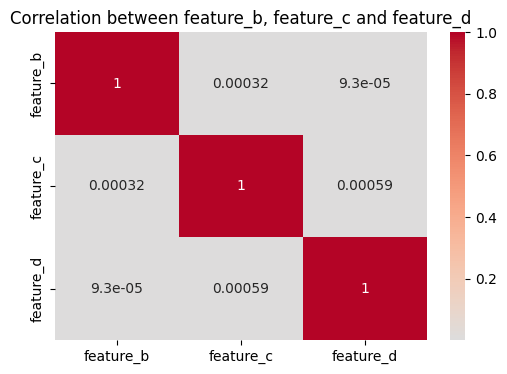

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = small_df[["feature_b", "feature_c", "feature_d"]].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between feature_b, feature_c and feature_d")
plt.show()


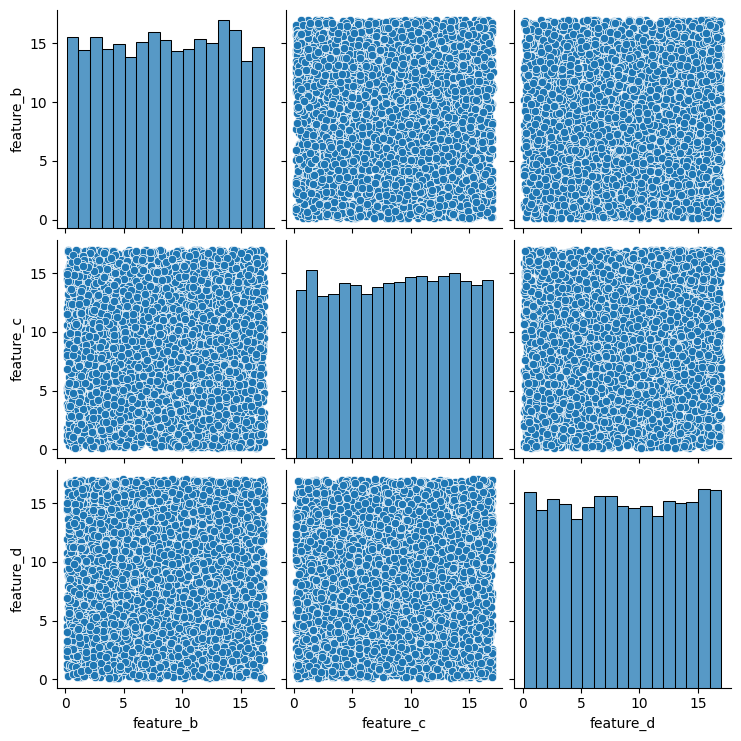

In [22]:
sample_plot = small_df[["feature_b", "feature_c", "feature_d"]].sample(5000, random_state=42)

sns.pairplot(sample_plot)
plt.show()


In [23]:
corr_df = pq.read_table(
    train,
    columns=feature_cols,
    use_threads=False
).to_pandas().sample(10000, random_state=42)

corr_matrix = corr_df.corr()

print(corr_matrix)


            feature_a  feature_b  feature_c  feature_d  feature_e  feature_f  \
feature_a    1.000000   0.005725  -0.006975   0.002209   0.014483   0.005010   
feature_b    0.005725   1.000000  -0.014529   0.017839  -0.009981   0.008057   
feature_c   -0.006975  -0.014529   1.000000   0.014592  -0.004879  -0.000759   
feature_d    0.002209   0.017839   0.014592   1.000000   0.019952  -0.006630   
feature_e    0.014483  -0.009981  -0.004879   0.019952   1.000000  -0.008401   
...               ...        ...        ...        ...        ...        ...   
feature_cd   0.114422   0.005542   0.014903   0.009164   0.013581   0.008758   
feature_ce  -0.013803  -0.002729   0.001539  -0.009846   0.003841  -0.005687   
feature_cf  -0.041832   0.005428  -0.001471   0.004323  -0.011266   0.013622   
feature_cg  -0.000082   0.009560  -0.006157  -0.002617   0.001625  -0.014053   
feature_ch   0.733437   0.006100  -0.006028   0.006054   0.022968   0.010367   

            feature_g  feature_h  featu

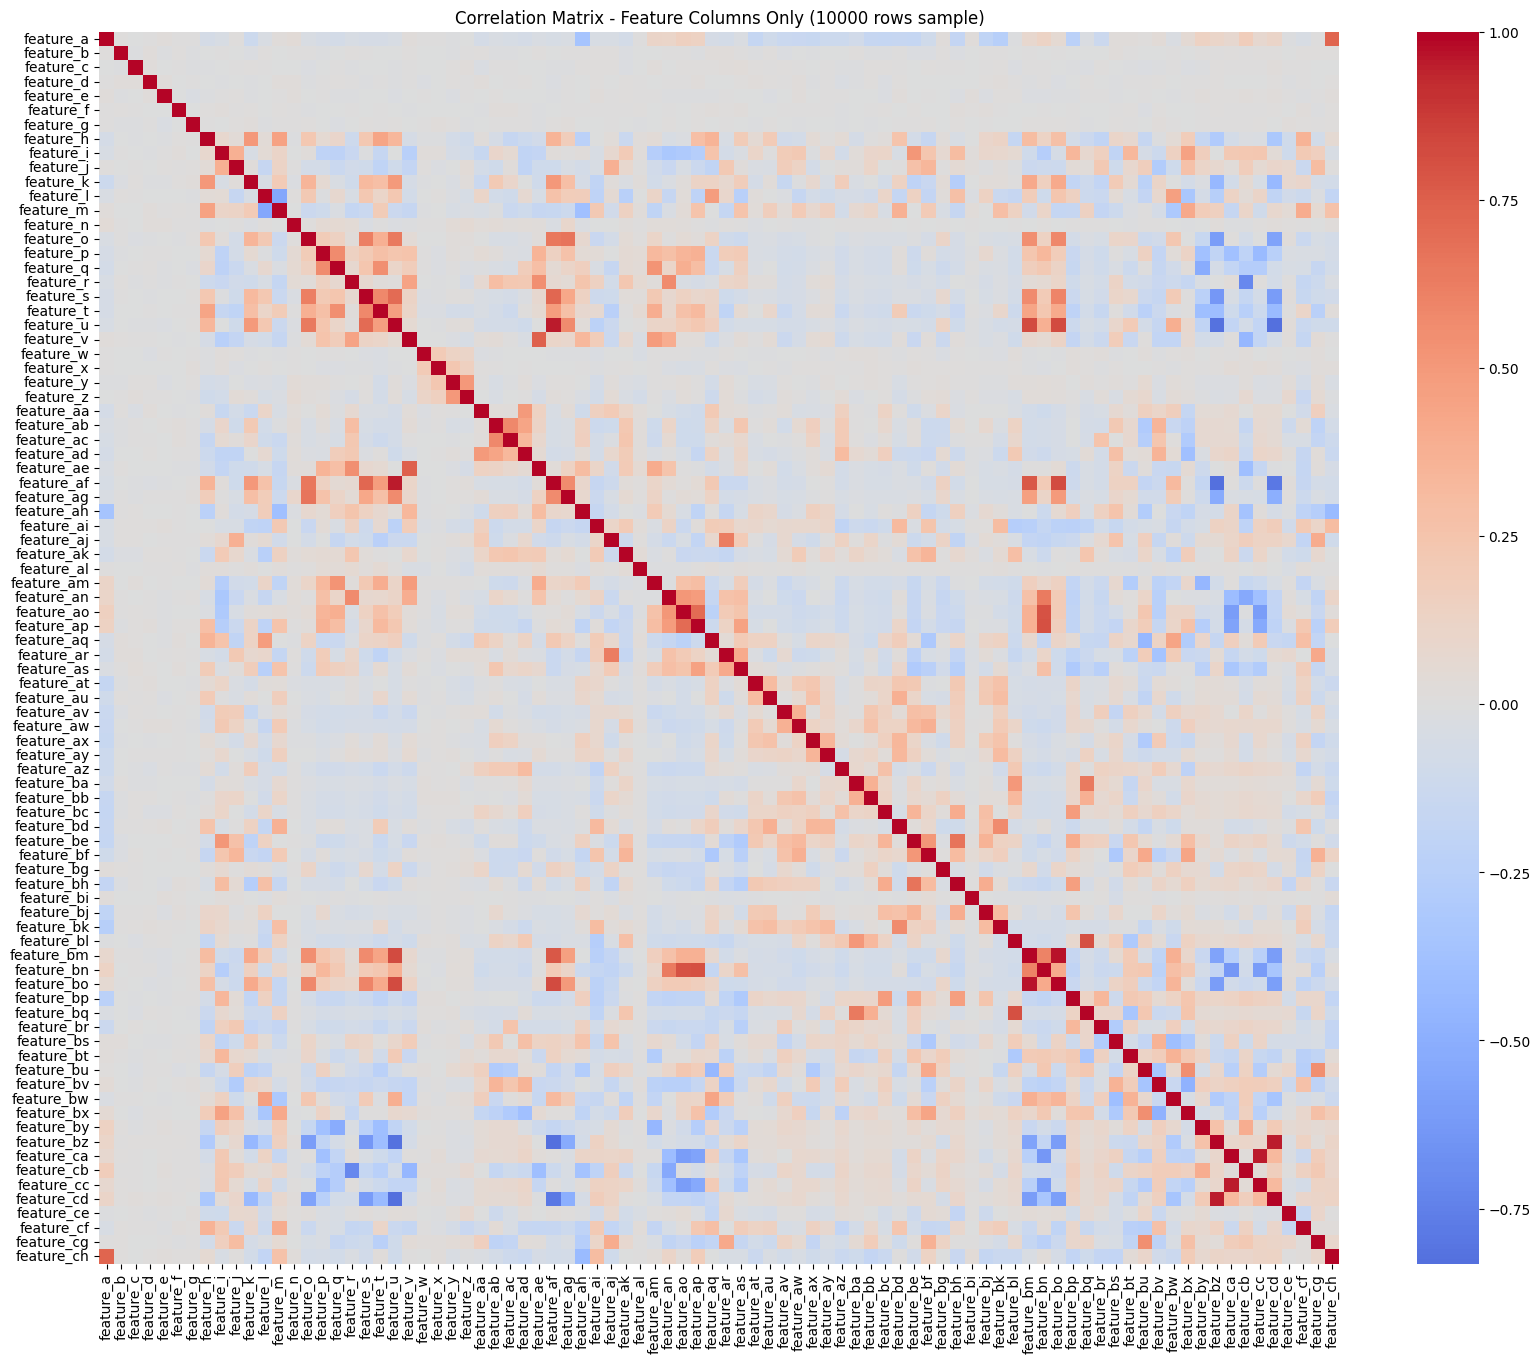

In [24]:
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Feature Columns Only (10000 rows sample)")
plt.show()


In [25]:
pairs = []

for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        c1 = feature_cols[i]
        c2 = feature_cols[j]
        corr_value = corr_matrix.loc[c1, c2]
        pairs.append([c1, c2, corr_value, abs(corr_value)])

pairs_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "corr", "abs_corr"])
pairs_df = pairs_df.sort_values("abs_corr", ascending=False)

print(pairs_df.head(20))


       feature_1   feature_2      corr  abs_corr
3425  feature_bm  feature_bo  0.969276  0.969276
1520   feature_u  feature_af  0.956050  0.956050
3628  feature_ca  feature_cc  0.955521  0.955521
3622  feature_bz  feature_cd  0.954381  0.954381
2215  feature_af  feature_bz -0.831782  0.831782
1570   feature_u  feature_cd -0.824733  0.824733
1555   feature_u  feature_bo  0.823218  0.823218
2204  feature_af  feature_bo  0.821912  0.821912
1553   feature_u  feature_bm  0.821775  0.821775
1566   feature_u  feature_bz -0.820255  0.820255
2688  feature_ap  feature_bn  0.805756  0.805756
3406  feature_bl  feature_bq  0.799959  0.799959
2644  feature_ao  feature_bn  0.794054  0.794054
2219  feature_af  feature_cd -0.791978  0.791978
2202  feature_af  feature_bm  0.771850  0.771850
1583   feature_v  feature_ae  0.745771  0.745771
84     feature_a  feature_ch  0.733437  0.733437
1389   feature_s  feature_af  0.717808  0.717808
1370   feature_r  feature_cb -0.714398  0.714398
2620  feature_ao  fe

In [26]:
train_inf = {}
test_inf = {}

for col in feature_cols:
    train_inf[col] = 0
    test_inf[col] = 0

for i in range(train_pf.num_row_groups):
    df = train_pf.read_row_group(i, columns=feature_cols).to_pandas()

    for col in feature_cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            train_inf[col] += np.isinf(df[col]).sum()

for i in range(test_pf.num_row_groups):
    df = test_pf.read_row_group(i, columns=feature_cols).to_pandas()

    for col in feature_cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            test_inf[col] += np.isinf(df[col]).sum()

print("infinite values check done")


infinite values check done


In [27]:
print (train_inf)
print (test_inf)

{'feature_a': 0, 'feature_b': 0, 'feature_c': 0, 'feature_d': 0, 'feature_e': 0, 'feature_f': 0, 'feature_g': 0, 'feature_h': 0, 'feature_i': 0, 'feature_j': 0, 'feature_k': 0, 'feature_l': 0, 'feature_m': 0, 'feature_n': 0, 'feature_o': 0, 'feature_p': 0, 'feature_q': 0, 'feature_r': 0, 'feature_s': 0, 'feature_t': 0, 'feature_u': 0, 'feature_v': 0, 'feature_w': 0, 'feature_x': 0, 'feature_y': 0, 'feature_z': 0, 'feature_aa': 0, 'feature_ab': 0, 'feature_ac': 0, 'feature_ad': 0, 'feature_ae': 0, 'feature_af': 0, 'feature_ag': 0, 'feature_ah': 0, 'feature_ai': 0, 'feature_aj': 0, 'feature_ak': 0, 'feature_al': 0, 'feature_am': 0, 'feature_an': 0, 'feature_ao': 0, 'feature_ap': 0, 'feature_aq': 0, 'feature_ar': 0, 'feature_as': 0, 'feature_at': 0, 'feature_au': 0, 'feature_av': 0, 'feature_aw': 0, 'feature_ax': 0, 'feature_ay': 0, 'feature_az': 0, 'feature_ba': 0, 'feature_bb': 0, 'feature_bc': 0, 'feature_bd': 0, 'feature_be': 0, 'feature_bf': 0, 'feature_bg': 0, 'feature_bh': 0, 'feat

In [28]:
for col in train_inf:
    if train_inf[col] > 0:
        print("train", col, train_inf[col])

for col in test_inf:
    if test_inf[col] > 0:
        print("test", col, test_inf[col])


In [29]:
TRAIN_PATH = train

eda_cols = ["id", "ts_index", "y_target", "weight", "code", "sub_code", "sub_category", "horizon"]
train_eda = pq.read_table(train, columns=eda_cols, use_threads=False).to_pandas()
train_eda = train_eda.sort_values("ts_index").reset_index(drop=True)


In [30]:
print(train_eda["ts_index"].head(10))
print(train_eda["ts_index"].tail(10))
print(train_eda["ts_index"].is_monotonic_increasing)



0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: ts_index, dtype: int32
5337404    3601
5337405    3601
5337406    3601
5337407    3601
5337408    3601
5337409    3601
5337410    3601
5337411    3601
5337412    3601
5337413    3601
Name: ts_index, dtype: int32
True


In [31]:
cut = train_eda["ts_index"].max() - 180 + 1
print(cut)


3422


In [32]:
train_part = train_eda[train_eda["ts_index"] < cut]
valid_part = train_eda[train_eda["ts_index"] >= cut]


In [33]:
print("train max ts_index:", train_part["ts_index"].max())
print("valid min ts_index:", valid_part["ts_index"].min())
print("cut:", cut)
print("train rows:", len(train_part))
print("valid rows:", len(valid_part))


train max ts_index: 3421
valid min ts_index: 3422
cut: 3422
train rows: 5036387
valid rows: 301027


In [34]:
sample_df = pq.read_table(
    TRAIN_PATH,
    columns=feature_cols,
    use_threads=False
).to_pandas().sample(100, random_state=42)

constant_cols = []

for col in feature_cols:
    if sample_df[col].nunique(dropna=False) == 1:
        constant_cols.append(col)

print(constant_cols)
print("number of possible constant columns:", len(constant_cols))



[]
number of possible constant columns: 0


In [35]:
cat_cols = ["code", "sub_code", "sub_category", "horizon"]

train_eda_encoded = train_eda.copy()

for col in cat_cols:
    train_eda_encoded[col] = train_eda_encoded[col].astype(str)

train_eda_encoded = pd.get_dummies(train_eda_encoded, columns=cat_cols)

print(train_eda_encoded.shape)
train_eda_encoded.head()


(5337414, 216)


,id,ts_index,y_target,weight,code_10BAVIDU,code_1HEMHZK2,code_2RBMUWP1,code_4KUR2ZOZ,code_660DZME0,code_6LB028J8,...,sub_code_ZYW0W9R9,sub_category_DPPUO5X2,sub_category_NQ58FVQM,sub_category_PHHHVYZI,sub_category_PZ9S1Z4V,sub_category_V8BKY1IV,horizon_1,horizon_10,horizon_25,horizon_3
0,VFWIFJPS__ODPORHON__DPPUO5X2__3__1,1,-0.003585,5.780602e+06,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1,OSJL3A7Y__SIJUOYMU__NQ58FVQM__1__1,1,-0.053631,8.174165e+01,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
2,OSJL3A7Y__SIJUOYMU__NQ58FVQM__10__1,1,0.777307,8.891558e+01,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,4KUR2ZOZ__JJKGJ8KH__V8BKY1IV__10__1,1,0.004218,1.668913e+02,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
4,4KUR2ZOZ__JJKGJ8KH__V8BKY1IV__3__1,1,-0.110289,2.016355e+02,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True


In [36]:
bool_cols = train_eda_encoded.select_dtypes(include="bool").columns
train_eda_encoded[bool_cols] = train_eda_encoded[bool_cols].astype(int)
print(train_eda_encoded.shape)
train_eda_encoded.head()


(5337414, 216)


,id,ts_index,y_target,weight,code_10BAVIDU,code_1HEMHZK2,code_2RBMUWP1,code_4KUR2ZOZ,code_660DZME0,code_6LB028J8,...,sub_code_ZYW0W9R9,sub_category_DPPUO5X2,sub_category_NQ58FVQM,sub_category_PHHHVYZI,sub_category_PZ9S1Z4V,sub_category_V8BKY1IV,horizon_1,horizon_10,horizon_25,horizon_3
0,VFWIFJPS__ODPORHON__DPPUO5X2__3__1,1,-0.003585,5.780602e+06,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,OSJL3A7Y__SIJUOYMU__NQ58FVQM__1__1,1,-0.053631,8.174165e+01,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
2,OSJL3A7Y__SIJUOYMU__NQ58FVQM__10__1,1,0.777307,8.891558e+01,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,4KUR2ZOZ__JJKGJ8KH__V8BKY1IV__10__1,1,0.004218,1.668913e+02,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
4,4KUR2ZOZ__JJKGJ8KH__V8BKY1IV__3__1,1,-0.110289,2.016355e+02,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1


In [37]:
sample_df = pq.read_table(
    TRAIN_PATH,
    columns=feature_cols,
    use_threads=False
).to_pandas().sample(10000, random_state=42)

low_var = []

for col in feature_cols:
    unique_values = sample_df[col].nunique(dropna=False)

    if unique_values <= 2:
        low_var.append([col, unique_values])

low_var_df = pd.DataFrame(low_var, columns=["feature", "num_unique_values"])
print(low_var_df)


Empty DataFrame
Columns: [feature, num_unique_values]
Index: []


In [38]:
print(train_eda["y_target"].describe())
print(train_eda["y_target"].quantile([0.001, 0.01, 0.05, 0.95, 0.99, 0.999]))


count    5.337414e+06
mean    -6.659048e-01
std      3.252764e+01
min     -2.201882e+03
25%     -1.290776e-01
50%     -5.774818e-04
75%      5.106807e-02
max      2.314411e+03
Name: y_target, dtype: float64
0.001   -337.473227
0.010    -82.797216
0.050     -7.606810
0.950      4.504747
0.990     62.923419
0.999    320.936998
Name: y_target, dtype: float64


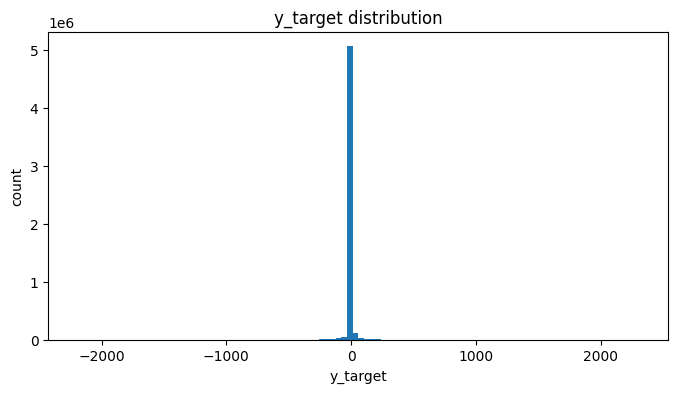

In [39]:
plt.figure(figsize=(8, 4))
plt.hist(train_eda["y_target"], bins=100)
plt.title("y_target distribution")
plt.xlabel("y_target")
plt.ylabel("count")
plt.show()


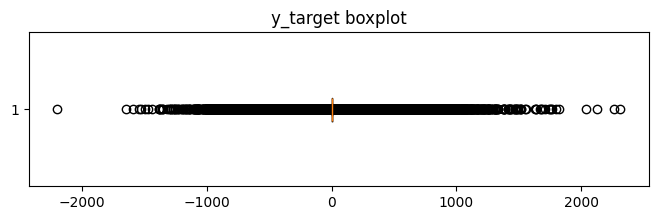

In [40]:
plt.figure(figsize=(8, 2))
plt.boxplot(train_eda["y_target"], vert=False)
plt.title("y_target boxplot")
plt.show()


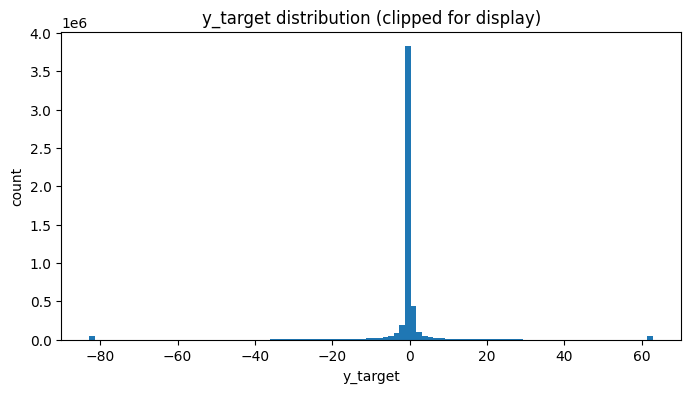

In [41]:
low = train_eda["y_target"].quantile(0.01)
high = train_eda["y_target"].quantile(0.99)

plt.figure(figsize=(8, 4))
plt.hist(train_eda["y_target"].clip(low, high), bins=100)
plt.title("y_target distribution (clipped for display)")
plt.xlabel("y_target")
plt.ylabel("count")
plt.show()


<Figure size 800x400 with 0 Axes>

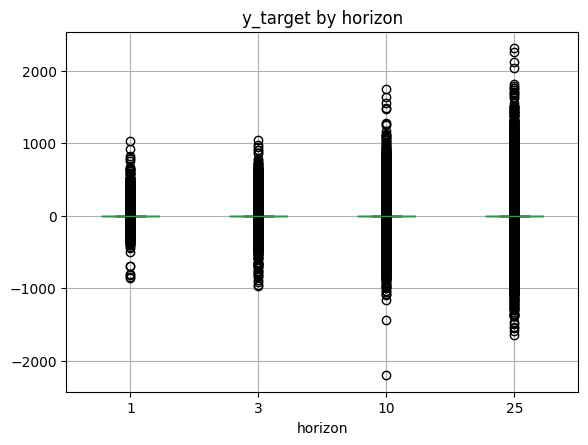

In [42]:
plt.figure(figsize=(8, 4))
train_eda.boxplot(column="y_target", by="horizon")
plt.title("y_target by horizon")
plt.suptitle("")
plt.show()


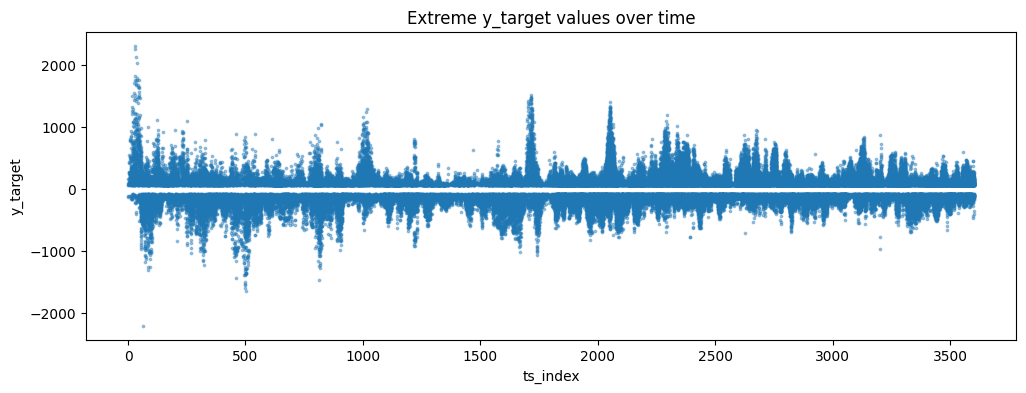

In [43]:
extreme_df = train_eda[
    (train_eda["y_target"] < train_eda["y_target"].quantile(0.01)) |
    (train_eda["y_target"] > train_eda["y_target"].quantile(0.99))
]

plt.figure(figsize=(12, 4))
plt.scatter(extreme_df["ts_index"], extreme_df["y_target"], s=3, alpha=0.4)
plt.title("Extreme y_target values over time")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()


In [44]:
print("missing y_target values:", train_eda["y_target"].isna().sum())
print("missing y_target percentage:", train_eda["y_target"].isna().mean())


missing y_target values: 0
missing y_target percentage: 0.0


In [45]:
threshold = 100
rows = []

for col in feature_cols:
    s = sample_df[col].dropna()

    q01 = s.quantile(0.01)
    q25 = s.quantile(0.25)
    q50 = s.quantile(0.50)
    q75 = s.quantile(0.75)
    q99 = s.quantile(0.99)

    iqr = q75 - q25

    if iqr != 0:
        lower_score = (q50 - q01) / iqr
        upper_score = (q99 - q50) / iqr
        max_score = max(lower_score, upper_score)

        if max_score > threshold:
            rows.append([col, q01, q50, q99, iqr, lower_score, upper_score, max_score])

outlier_df = pd.DataFrame(
    rows,
    columns=["feature", "q01", "median", "q99", "iqr", "lower_score", "upper_score", "max_score"]
)

outlier_df = outlier_df.sort_values("max_score", ascending=False)
print(outlier_df)


       feature           q01      median            q99          iqr  \
5   feature_ag  4.891845e-09    0.000111      27.294345     0.004966   
6   feature_al -2.653851e+01   -0.000169      24.317358     0.028750   
1    feature_o  0.000000e+00    0.004324      27.892488     0.039273   
9   feature_bo  1.432012e-02    3.430456    8347.191986    12.545334   
3    feature_u  6.713693e-04    0.083111     509.867704     0.818983   
10  feature_bq  5.170565e-04    0.184079     257.721351     1.337494   
8   feature_bl  1.114396e-04    0.070686     127.319389     0.762764   
2    feature_r  2.166571e-04    0.012968      10.396942     0.068712   
12  feature_cd -1.454253e+01   -0.001561      -0.000056     0.100415   
4   feature_af  1.126611e-03    0.212008     742.972224     5.132183   
11  feature_cc -7.889491e+00   -0.013540      -0.000007     0.058457   
7   feature_ba  0.000000e+00  197.015381  633492.586939  4776.164935   
0    feature_n -3.514841e+00   -0.000343       3.426201     0.03

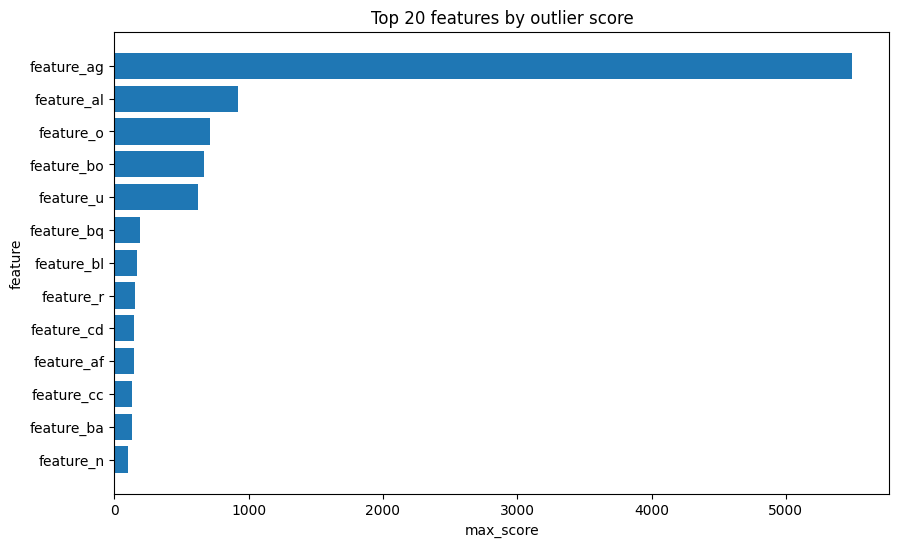

In [46]:
top_df = outlier_df.sort_values("max_score", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_df["feature"], top_df["max_score"])
plt.gca().invert_yaxis()
plt.title("Top 20 features by outlier score")
plt.xlabel("max_score")
plt.ylabel("feature")
plt.show()


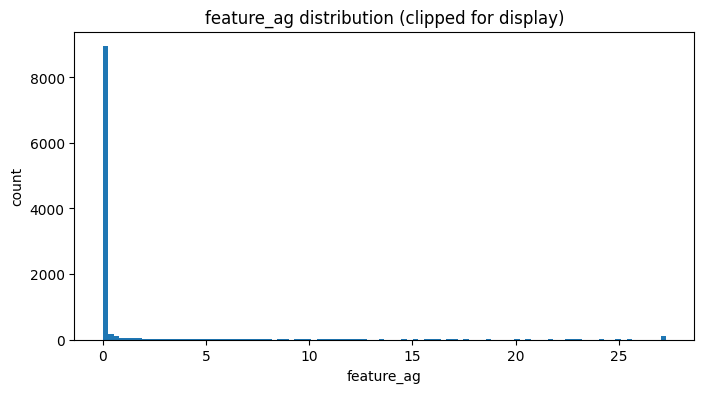

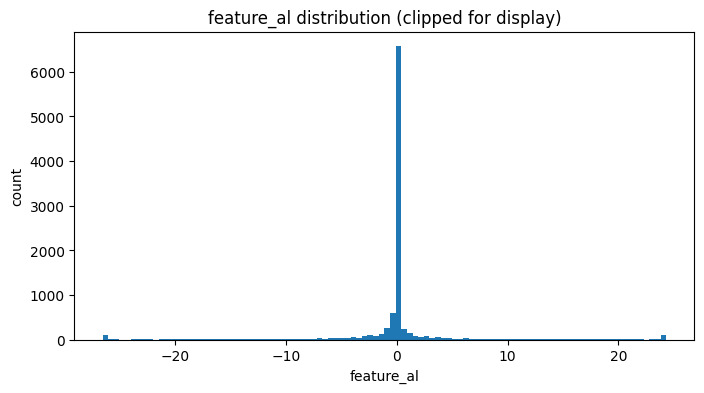

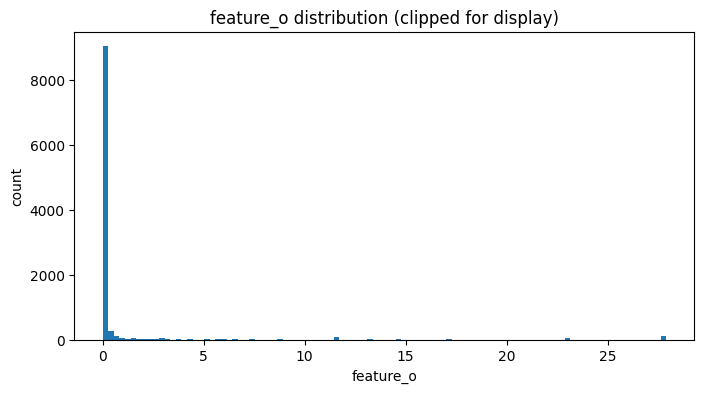

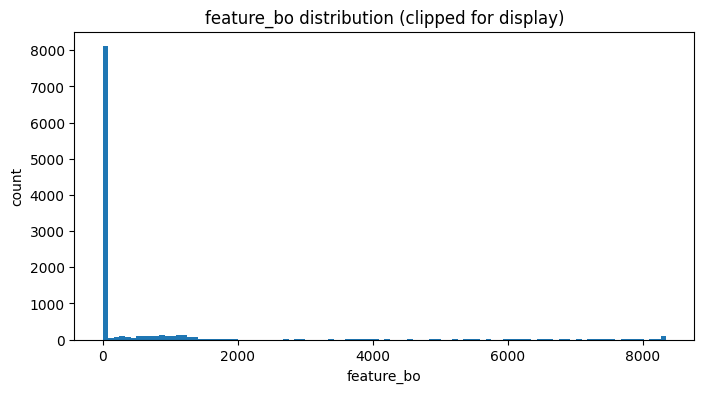

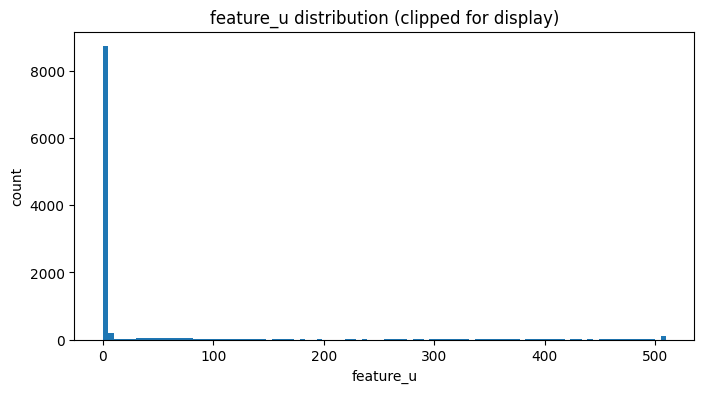

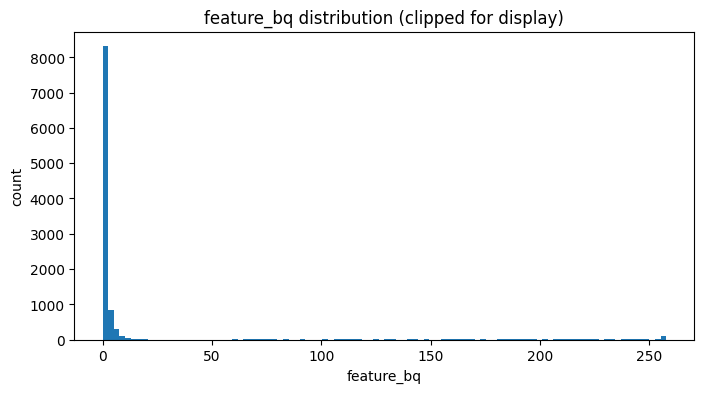

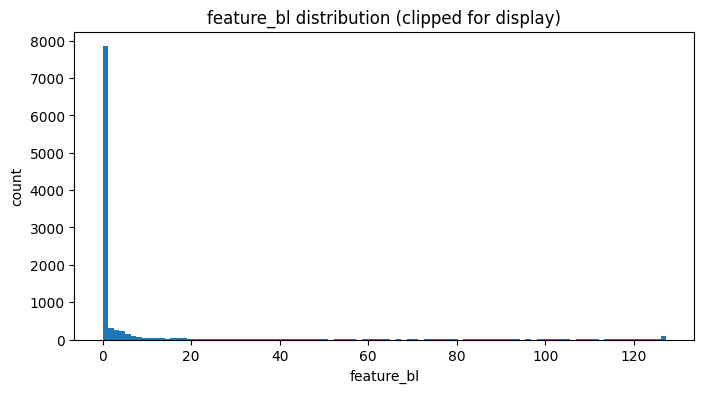

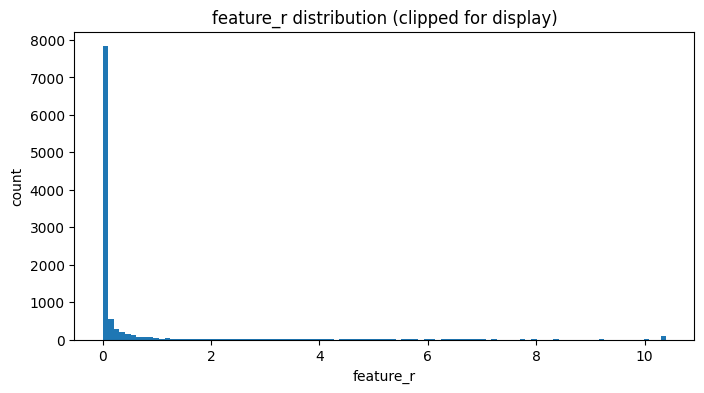

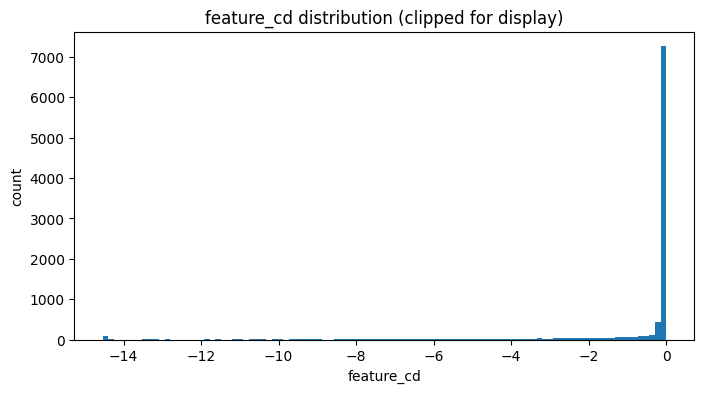

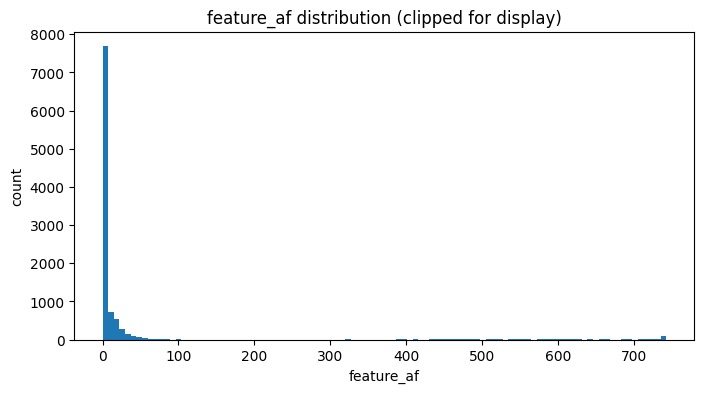

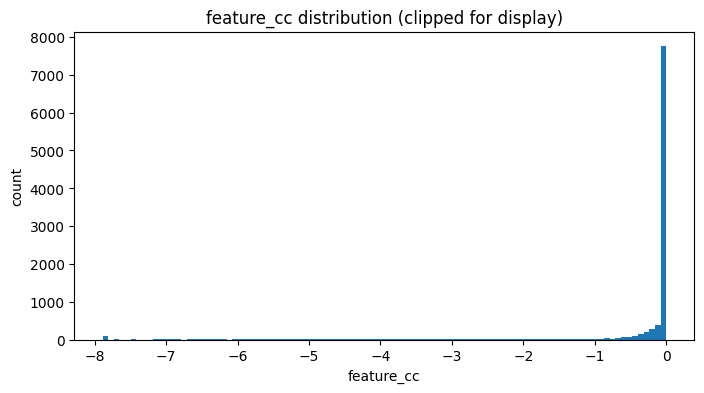

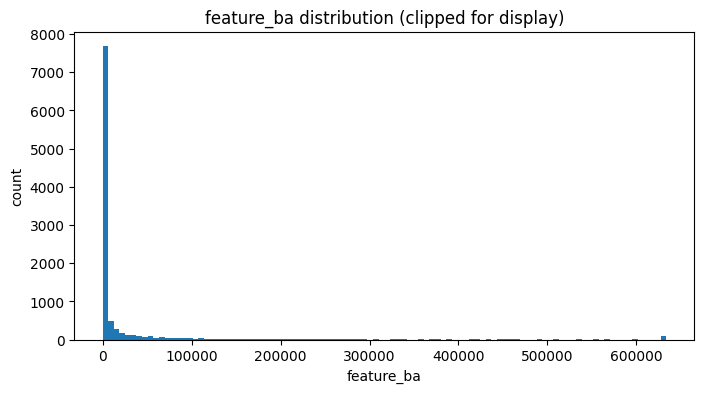

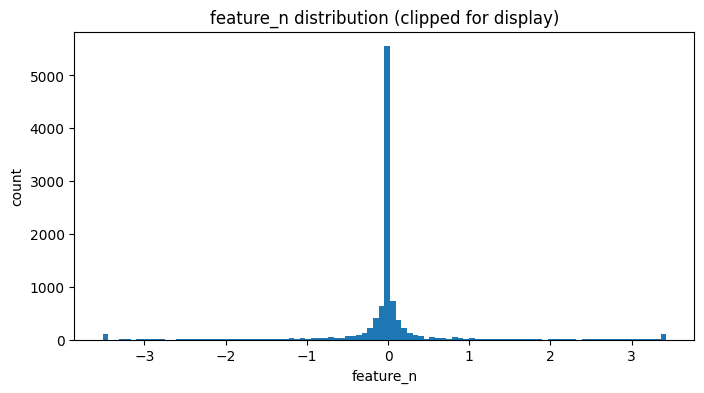

In [47]:
cols_to_plot = outlier_df["feature"].tolist()

for col in cols_to_plot:
    low = sample_df[col].quantile(0.01)
    high = sample_df[col].quantile(0.99)

    plt.figure(figsize=(8, 4))
    plt.hist(sample_df[col].dropna().clip(low, high), bins=100)
    plt.title(f"{col} distribution (clipped for display)")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()


In [48]:
cols_to_plot = outlier_df.sort_values("max_score", ascending=False)["feature"].head(5).tolist()

feature_time_df = pq.read_table(
    TRAIN_PATH,
    columns=["ts_index"] + cols_to_plot,
    use_threads=False
).to_pandas()


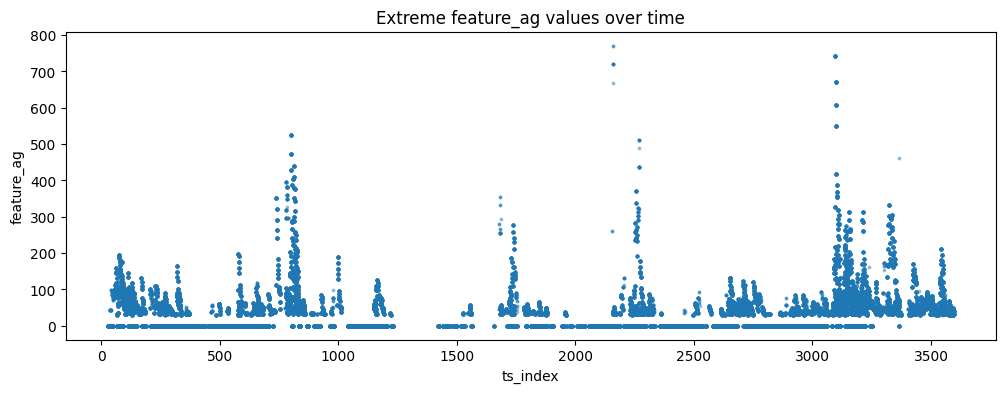

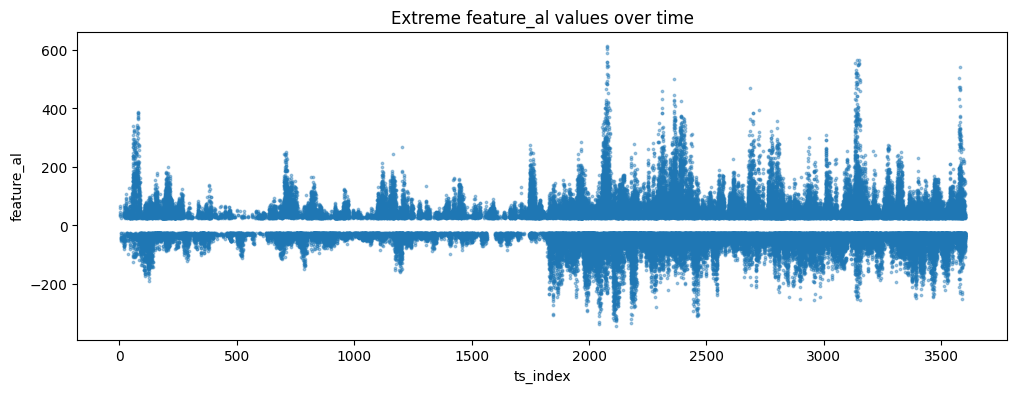

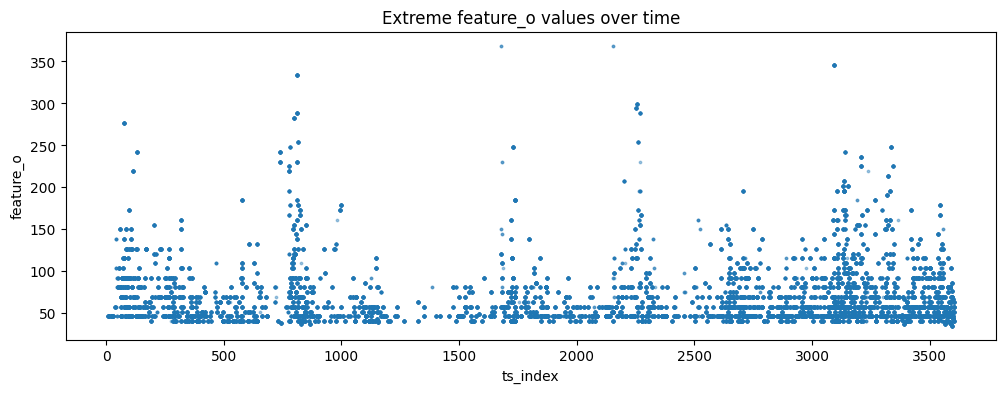

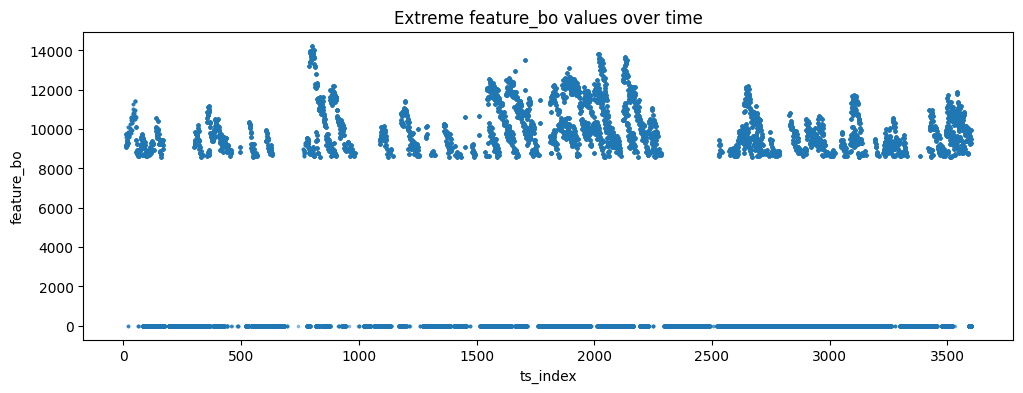

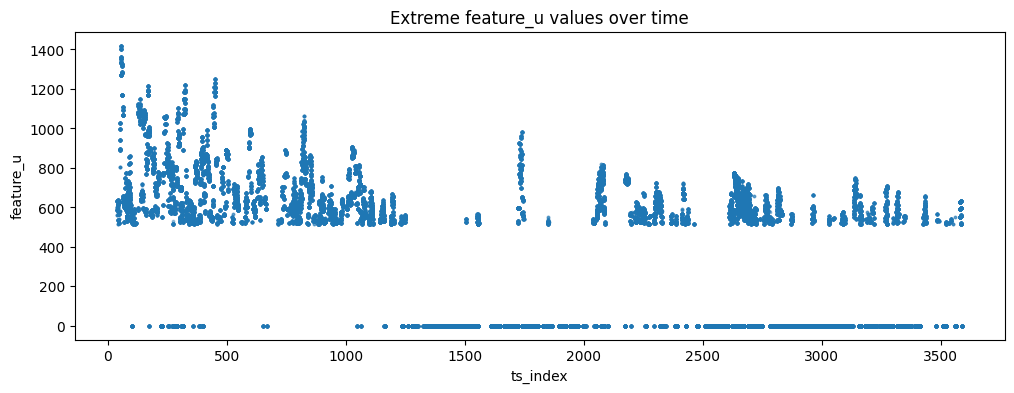

In [49]:
for col in cols_to_plot:
    low = feature_time_df[col].quantile(0.01)
    high = feature_time_df[col].quantile(0.99)

    extreme_df = feature_time_df[
        (feature_time_df[col] < low) |
        (feature_time_df[col] > high)
    ]

    plt.figure(figsize=(12, 4))
    plt.scatter(extreme_df["ts_index"], extreme_df[col], s=3, alpha=0.4)
    plt.title(f"Extreme {col} values over time")
    plt.xlabel("ts_index")
    plt.ylabel(col)
    plt.show()


In [50]:

def plot_histograms_near_bulk(
    df,
    columns,
    bins=80,
    upper_q=0.99,
    lower_q_signed=0.01,
    manual_xlim=None,
    figsize_per_row=(14, 4),
):
    manual_xlim = manual_xlim or {}
    n = len(columns)
    fig, axes = plt.subplots(n, 2, figsize=(figsize_per_row[0], figsize_per_row[1] * n))

    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(columns):
        s = df[col].replace([np.inf, -np.inf], np.nan).dropna()

        ax_full = axes[i, 0]
        ax_zoom = axes[i, 1]

        ax_full.hist(s, bins=bins, color="steelblue", edgecolor="white", alpha=0.85)
        ax_full.set_title(f"{col} - full range")
        ax_full.set_xlabel(col)
        ax_full.set_ylabel("count")

        if col in manual_xlim:
            low, high = manual_xlim[col]
        else:
            if (s >= 0).all():
                low = 0.0
                high = s.quantile(upper_q)
            else:
                low = s.quantile(lower_q_signed)
                high = s.quantile(upper_q)
        if not np.isfinite(low) or not np.isfinite(high) or low == high:
            low, high = s.min(), s.max()

        s_zoom = s[(s >= low) & (s <= high)]

        ax_zoom.hist(s_zoom, bins=bins, color="darkorange", edgecolor="white", alpha=0.85)
        ax_zoom.set_xlim(low, high)
        ax_zoom.set_title(f"{col} - zoomed [{low:.3g}, {high:.3g}]")
        ax_zoom.set_xlabel(col)
        ax_zoom.set_ylabel("count")

    plt.tight_layout()
    plt.show()


Existing: ['feature_ag', 'feature_ai', 'feature_o', 'feature_bo', 'feature_u', 'feature_bq', 'feature_bl', 'feature_r', 'feature_cd', 'feature_af', 'feature_cc', 'feature_ba', 'feature_n']
Missing: []


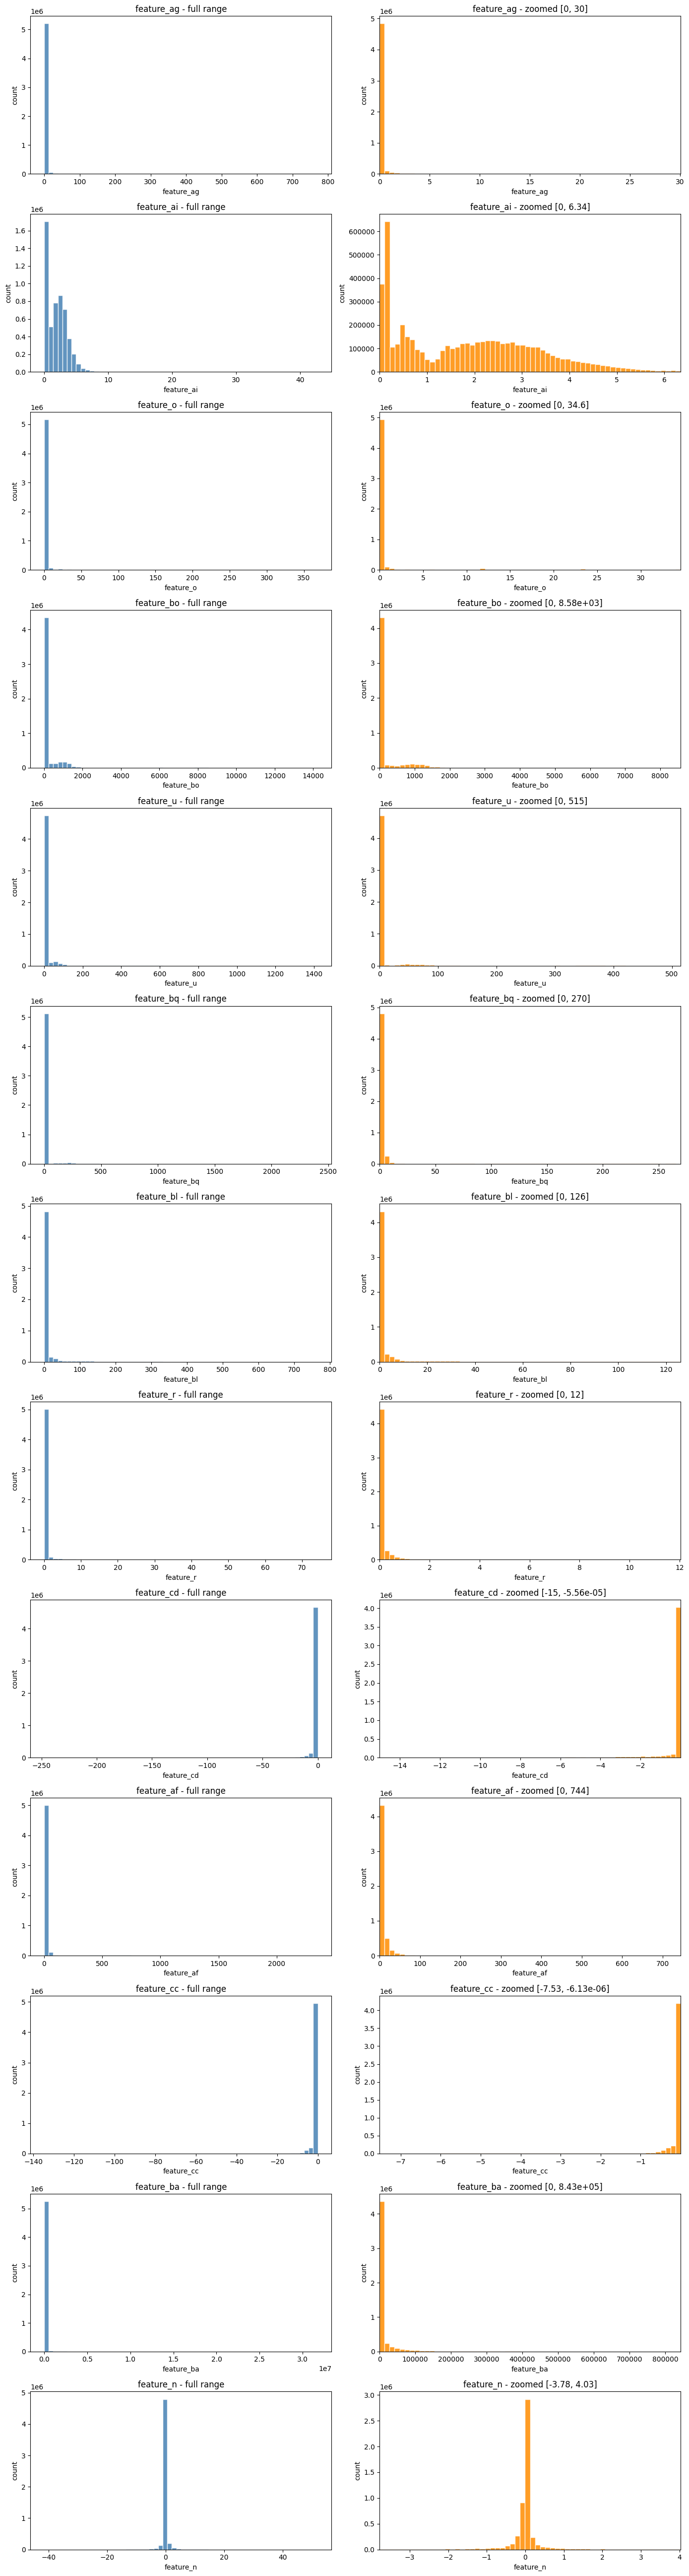

In [51]:
import pandas as pd

train_raw = pd.read_parquet(TRAIN_PATH)

cols = [
    "feature_ag", "feature_ai", "feature_o", "feature_bo", "feature_u",
    "feature_bq", "feature_bl", "feature_r", "feature_cd",
    "feature_af", "feature_cc", "feature_ba", "feature_n"
]

existing_cols = [c for c in cols if c in train_raw.columns]
missing_cols = [c for c in cols if c not in train_raw.columns]

print("Existing:", existing_cols)
print("Missing:", missing_cols)

plot_histograms_near_bulk(train_raw, existing_cols, bins=60)


In [52]:
def plot_histograms_near_bulk(df, columns, bins=80, manual_xlim=None):
    manual_xlim = manual_xlim or {}
    n = len(columns)
    fig, axes = plt.subplots(n, 3, figsize=(18, 4 * n))

    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(columns):
        s = df[col].replace([np.inf, -np.inf], np.nan).dropna()

        ax_full = axes[i, 0]
        ax_zoom = axes[i, 1]
        ax_log = axes[i, 2]

        # full histogram
        ax_full.hist(s, bins=bins, color="steelblue", edgecolor="white", alpha=0.85)
        ax_full.set_title(f"{col} - full range")
        ax_full.set_xlabel(col)
        ax_full.set_ylabel("count")

        # zoomed histogram
        if col in manual_xlim:
            low, high = manual_xlim[col]
        else:
            if (s >= 0).all():
                low, high = 0, s.quantile(0.99)
            else:
                low, high = s.quantile(0.01), s.quantile(0.99)

        s_zoom = s[(s >= low) & (s <= high)]
        ax_zoom.hist(s_zoom, bins=bins, color="darkorange", edgecolor="white", alpha=0.85)
        ax_zoom.set_xlim(low, high)
        ax_zoom.set_title(f"{col} - zoomed [{low:.3g}, {high:.3g}]")
        ax_zoom.set_xlabel(col)
        ax_zoom.set_ylabel("count")

        # log1p histogram
        if (s >= 0).all():
            s_log = np.log1p(s)
            ax_log.hist(s_log, bins=bins, color="seagreen", edgecolor="white", alpha=0.85)
            ax_log.set_title(f"{col} - log1p")
            ax_log.set_xlabel(f"log1p({col})")
            ax_log.set_ylabel("count")
        else:
            ax_log.text(0.5, 0.5, "negative values present", ha="center", va="center")
            ax_log.set_title(f"{col} - log1p not applied")
            ax_log.set_axis_off()

    plt.tight_layout()
    plt.show()


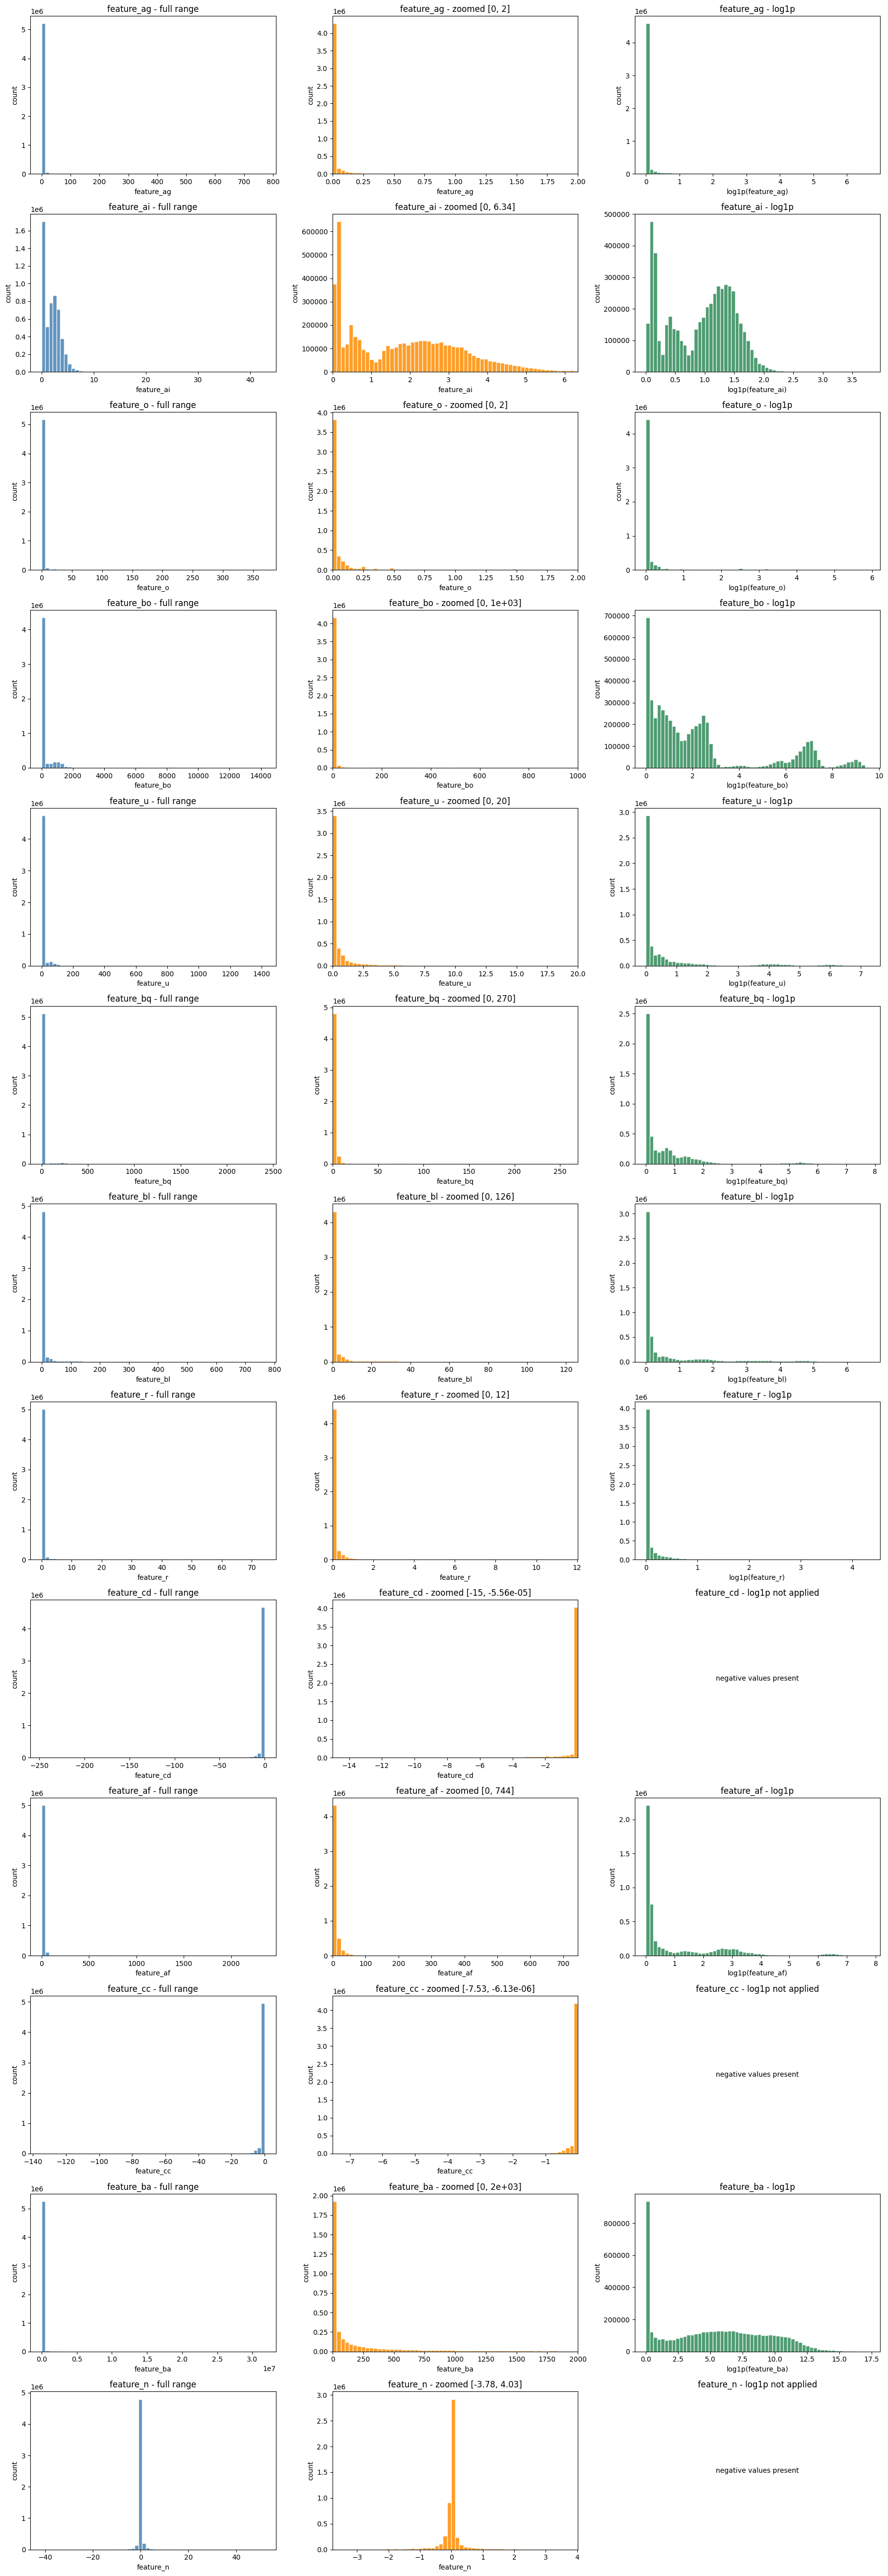

In [53]:
plot_histograms_near_bulk(
    train_raw,
    existing_cols,
    bins=60,
    manual_xlim={
        "feature_ag": (0, 2),
        "feature_o": (0, 2),
        "feature_bo": (0, 1000),
        "feature_u": (0, 20),
        "feature_ba": (0, 2000),
    }
)
